# 06 · ANALYZE — Q3: pérdidas potenciales, precio de quiebre, VaR y escenarios

In [1]:
import sys, warnings, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)
from IPython.display import Image, display
from src.analysis import correr_todo
R = correr_todo(); q3 = R['q3']
display(q3['breakeven'].T)

,0,1
tipo,Manufacturera,Pesquera
precio_breakeven_usd_t,160.2198,1336.9526
ic95_inf,-1012.1863,1213.0989
ic95_sup,1332.6259,1460.8064
efecto_100usd_pp,0.3016,0.9833
efecto_ic95_inf,0.049,0.6559
efecto_ic95_sup,0.5543,1.3106
r2,0.2954,0.7355
precio_min_observado,1170.4167,1170.4167
precio_max_observado,2126.9167,2126.9167


In [2]:
display(q3['var'].round(3))

,tipo,metrica,media_empresa,mediana_empresa,VaR95_empresa,CVaR95_empresa,media_agregado,min_agregado,VaR95_agregado,n_empresa_anio,n_anios
0,Manufacturera,margen_bruto,0.173,0.141,0.036,-0.040,0.134,0.100,0.105,375,14
1,Manufacturera,margen_operativo,0.035,0.026,-0.027,-0.181,0.043,0.020,0.024,397,14
2,Manufacturera,margen_neto,0.020,0.018,-0.033,-0.169,0.026,0.008,0.013,422,15
3,Pesquera,margen_bruto,0.210,0.162,0.003,-0.163,0.166,0.121,0.124,1056,14
4,Pesquera,margen_operativo,0.024,0.018,-0.177,-0.436,0.025,-0.044,-0.016,1206,14
5,Pesquera,margen_neto,0.008,0.010,-0.174,-0.433,0.010,-0.049,-0.023,1270,15


In [3]:
display(q3['escenarios'])

,tipo,escenario,precio_usd_t,margen_op_esperado_pct,pi95_inf_pct,pi95_sup_pct,cambio_vs_2025_pp,impacto_utilidad_operativa_musd,pct_empresas_en_perdida,pct_empresas_perdida_2025
0,Manufacturera,Mínimo histórico (oct-2019),900,2.23,-0.96,5.42,-2.03,-26.69,32.26,3.23
1,Manufacturera,Piso El Niño 2015,1100,2.83,-0.13,5.80,-1.43,-18.76,22.58,3.23
2,Manufacturera,Precio promedio 2024,1438,3.85,1.08,6.63,-0.41,-5.36,9.68,3.23
3,Manufacturera,Precio promedio 2025,1573,4.26,1.50,7.03,-0.00,-0.01,3.23,3.23
4,Manufacturera,Moderado alto (prom. 2013),1800,4.95,2.10,7.79,0.68,8.99,3.23,3.23
5,Manufacturera,Severo (prom. 2012),2100,5.85,2.74,8.97,1.59,20.88,0.00,3.23
6,Manufacturera,Extremo (pico oct-2017 / sep-2026),2300,6.45,3.07,9.83,2.19,28.81,0.00,3.23
7,Manufacturera,Estrés extremo,2500,7.06,3.36,10.75,2.80,36.74,0.00,3.23
8,Pesquera,Mínimo histórico (oct-2019),900,-4.30,-8.47,-0.12,-6.62,-74.30,74.04,15.38
9,Pesquera,Piso El Niño 2015,1100,-2.33,-6.18,1.52,-4.65,-52.23,68.27,15.38


In [4]:
display(q3['perdidas_anio'].pivot(index='anio', columns='tipo_empresa', values='pct_perdida_operativa').round(3))
print(q3['shock_velocidad_manuf'])

tipo_empresa,Manufacturera,Pesquera
anio,,
2011,0.045,0.125
2012,0.192,0.190
2013,0.107,0.156
2014,NaN,NaN
2015,0.125,0.347
2016,0.292,0.299
2017,0.261,0.135
2018,0.154,0.150
2019,0.143,0.219


{'coef_pp_por_10pct': -0.6821, 'ic95': [-1.1124, -0.2519], 'p_value': 0.002, 'impacto_musd_shock_30pct': -26.894888759258397}


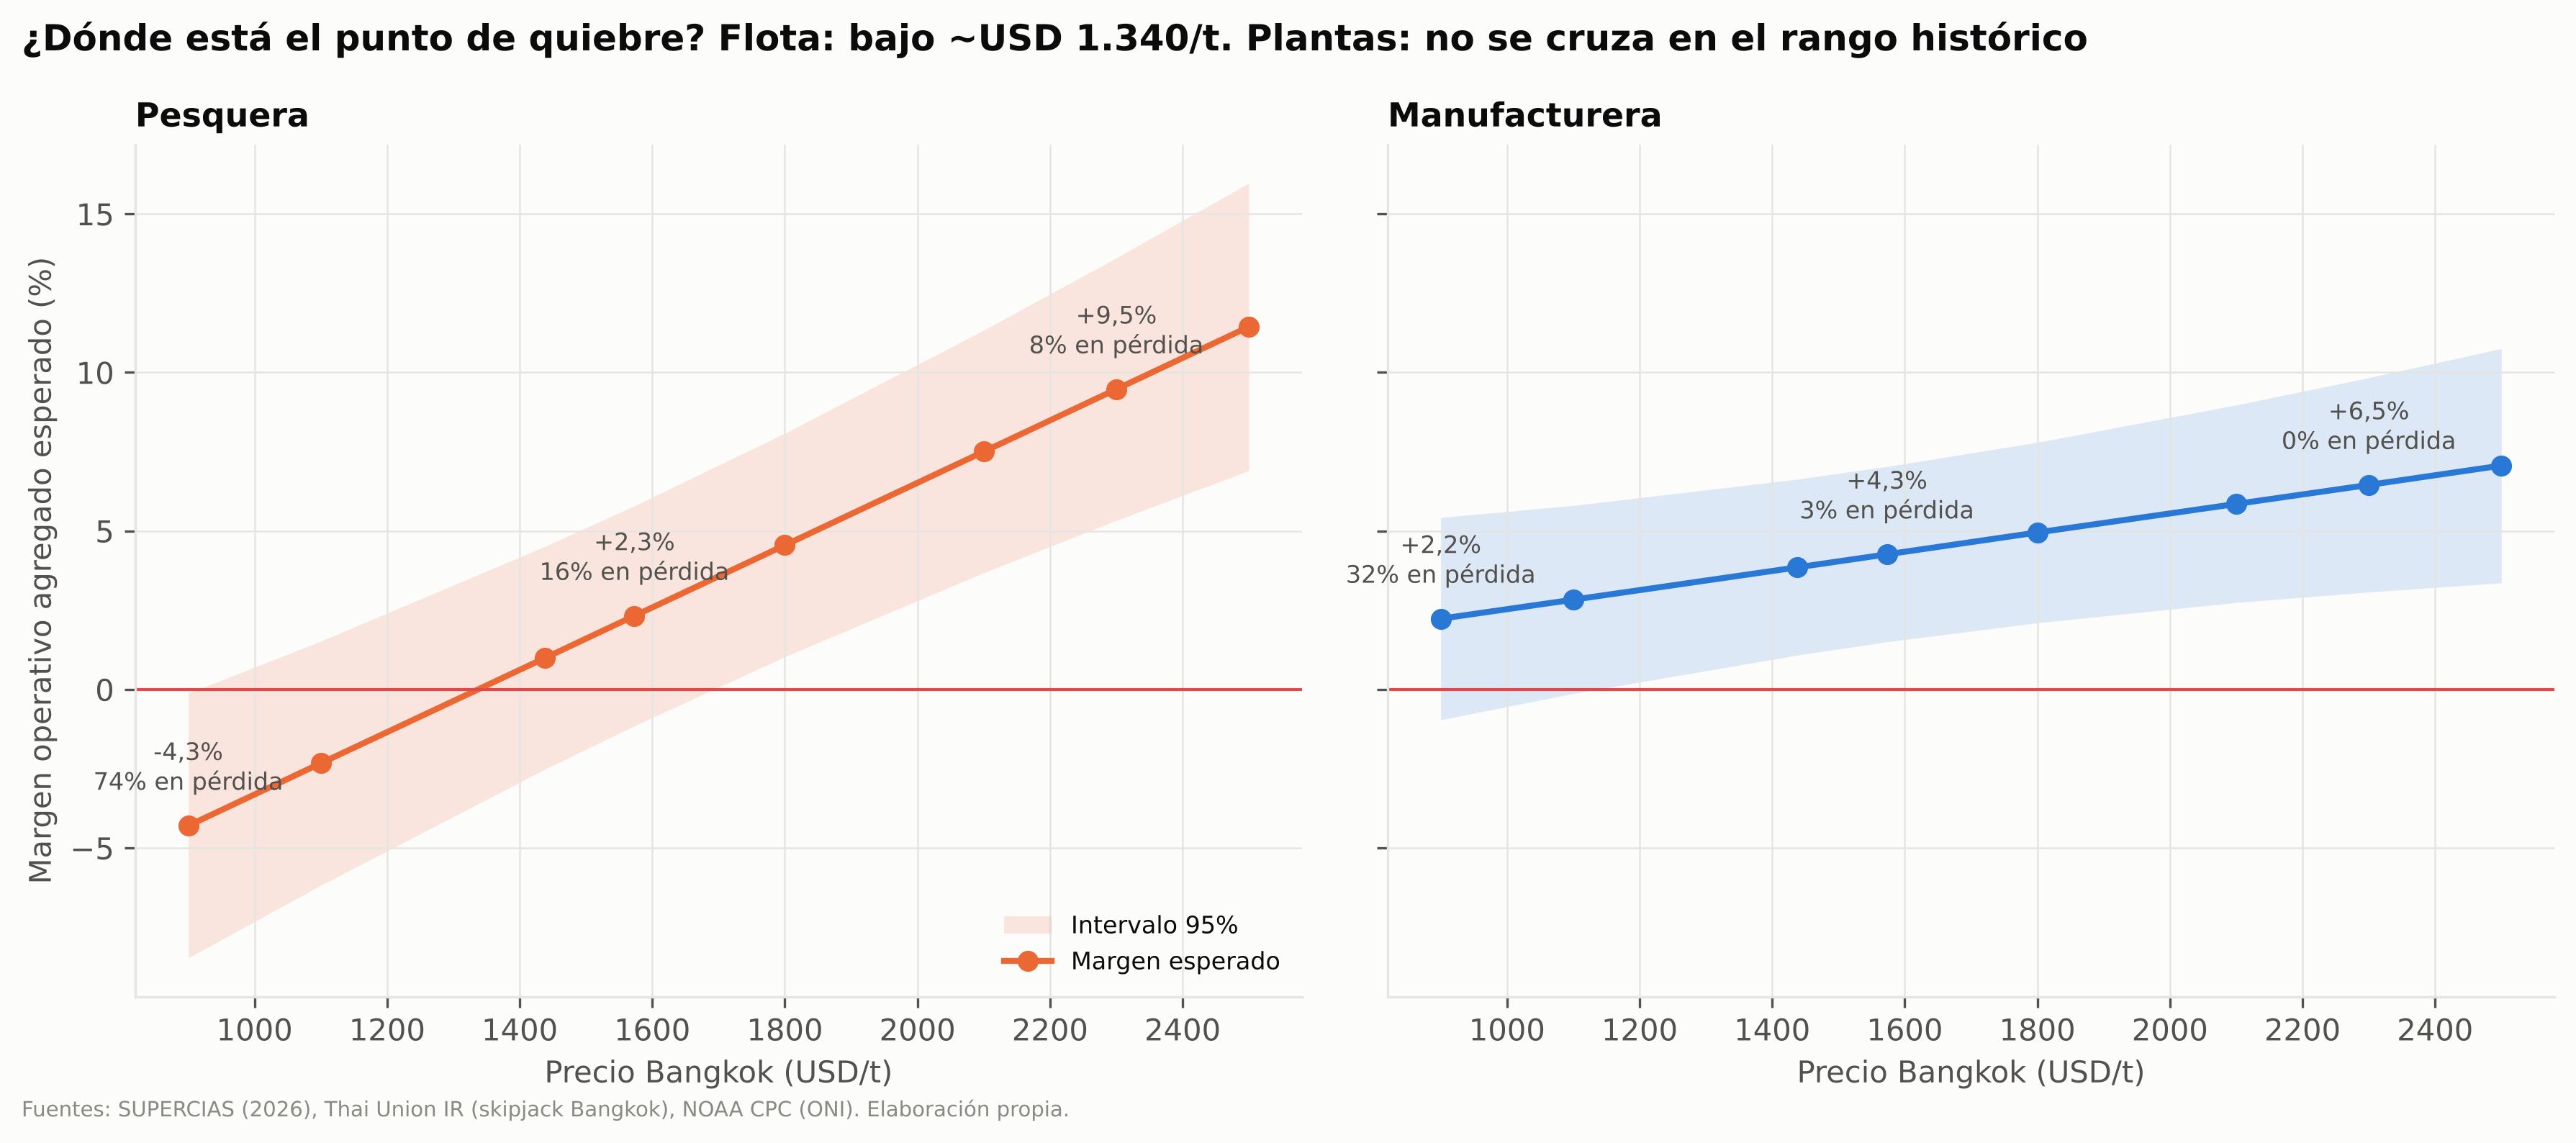

In [5]:
display(Image('../outputs/figures/fig6_escenarios_estres.png', width=950))

### Lectura
- **Armadores:** precio de quiebre operativo ≈ **USD 1.340/t** (IC95 ≈ 1.210–1.460), dentro del rango observado. Los años con margen operativo agregado negativo (2015, 2019) son justamente los de precio < USD 1.250.
  Con USD 900/t, ~74% de las empresas tendría pérdida operativa; impacto ≈ −USD 74 M en utilidad operativa frente a 2025.
- **Plantas:** el margen operativo agregado **nunca** fue negativo en 2011–2025. El quiebre extrapolado (≈ USD 160/t) está fuera de rango y no es interpretable.
  Su riesgo real es de **velocidad**: un salto de +30% en el año implica ≈ −2 pp de margen bruto (≈ −USD 27 M sobre las ventas de 2025).
- **VaR 95% (empresa-año):** margen operativo −2,7% en plantas vs −17,7% en flota. La flota tiene una cola mucho más pesada.